# 1. 使用get_current_fig_manager函数获取Figure对象管理器

In [1]:
import matplotlib.pyplot as plt
plt.get_current_fig_manager()

<Figure size 640x480 with 0 Axes>

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mlp
mlp.use("Qt5Agg")
plt.get_current_fig_manager()

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mlp
mlp.use("inline")
plt.get_current_fig_manager()

<Figure size 640x480 with 0 Axes>

In [2]:
%matplotlib qt
import matplotlib.pyplot as plt
plt.get_current_fig_manager()

- 代码说明：
    - 使用use函数与魔法指令可以指定后端类型。
    - 使用matplotlib.get_backend可以得到后端信息。
    - 上面代码每个单元格需要重新启动内核后运行。

In [2]:
import matplotlib as mlp
mlp.get_backend()

'module://matplotlib_inline.backend_inline'

In [1]:
%matplotlib qt
import matplotlib as mlp
mlp.get_backend()

'qtagg'

In [1]:
import matplotlib as mlp
mlp.use("notebook")
mlp.get_backend()

'notebook'

# 2. 使用new_figure_manager创建管理器

- 交互式平台的使用。

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure
from matplotlib import _pylab_helpers
import numpy as np

mpl.use("Qt5Agg")

fig = Figure(figsize=(3, 2), dpi=100)
fig.suptitle("Hello")    
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot([0.1, 0.9], [0.5, 0.5])

manager = plt.new_figure_manager(num=1)  # 自动判别平台，创建管理器
manager.canvas.figure = fig
# manager.canvas.draw()  # 强制刷新
# _pylab_helpers.Gcf.set_active(manager)   # 激活就可以使用。
_pylab_helpers.Gcf._set_new_active_manager(manager)
plt.show()


- 代码说明：
    - `_pylab_helpers.Gcf.set_active(manager)`代码可以确保Figure对象被pyplot能够管理。

- 非交互式平台

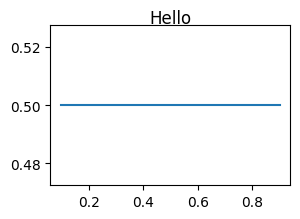

In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.backends.backend_agg import FigureManagerBase
from matplotlib.figure import Figure
from matplotlib import _pylab_helpers
import numpy as np

# mpl.use("inline")   # 'agg', 'svg', 'pdf', 'ps'，非交互式与平台无关

fig = Figure(figsize=(3, 2), dpi=100)
fig.suptitle("Hello")    
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot([0.1, 0.9], [0.5, 0.5])

canvas = FigureCanvasAgg(fig)
fig.set_canvas(canvas)
manager = plt.new_figure_manager(num=1)  # 自动判别平台，创建管理器
manager.canvas.figure = fig
manager.canvas = canvas
# _pylab_helpers.Gcf.set_active(manager)  
_pylab_helpers.Gcf._set_new_active_manager(manager)
canvas.draw()
# canvas.print_figure("demo")   # png
# fig.savefig("demo")

plt.savefig("demo.pdf")  # pyplot起作用了。
plt.show()

- 代码说明：
    - FingureManager的作用就体现在使用fig

-----

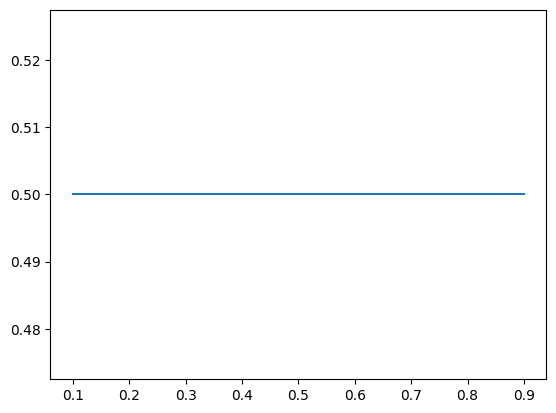

Figure(640x480)


<Figure size 640x480 with 0 Axes>

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot([0.1, 0.9], [0.5, 0.5])
plt.show()

print(plt.get_current_fig_manager())
print(plt.get_current_fig_manager().canvas)
print(plt.gcf())
print(plt.gcf().canvas)


In [8]:
import matplotlib
# 必须先设置后端
matplotlib.use('Agg')  # 非交互式后端

from matplotlib.backends.backend_agg import new_figure_manager

# 创建图形管理器
manager = new_figure_manager(num=1, figsize=(8, 6), dpi=100)

# 获取图形对象
fig = manager.canvas.figure

# 在图形上绘图
ax = fig.add_subplot(111)
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title('new_figure_manager')

# 渲染并保存
# fig.savefig('figure_from_manager.png')
manager.show()

NonGuiException: FigureCanvasAgg is non-interactive, and thus cannot be shown